In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy.stats import weibull_min



# --- 2. 找到所有以 Run 开头的 csv 文件 ---
files = glob.glob('../../dataset/POD/Run*/*.csv') # 自动匹配 Run1.csv, Run2.csv 等
files.sort() # 排序确保顺序一致

print(f"找到 {len(files)} 个文件：{files}")

找到 16 个文件：['../../dataset/POD\\Run10\\pod_energy_spectrum.csv', '../../dataset/POD\\Run10\\pod_fft_spectrum.csv', '../../dataset/POD\\Run10\\pod_phase_mode0_mode1.csv', '../../dataset/POD\\Run10\\pod_temporal_coefficients.csv', '../../dataset/POD\\Run11\\pod_energy_spectrum.csv', '../../dataset/POD\\Run11\\pod_fft_spectrum.csv', '../../dataset/POD\\Run11\\pod_phase_mode0_mode1.csv', '../../dataset/POD\\Run11\\pod_temporal_coefficients.csv', '../../dataset/POD\\Run12\\pod_energy_spectrum.csv', '../../dataset/POD\\Run12\\pod_fft_spectrum.csv', '../../dataset/POD\\Run12\\pod_phase_mode0_mode1.csv', '../../dataset/POD\\Run12\\pod_temporal_coefficients.csv', '../../dataset/POD\\Run2\\pod_energy_spectrum.csv', '../../dataset/POD\\Run2\\pod_fft_spectrum.csv', '../../dataset/POD\\Run2\\pod_phase_mode0_mode1.csv', '../../dataset/POD\\Run2\\pod_temporal_coefficients.csv']


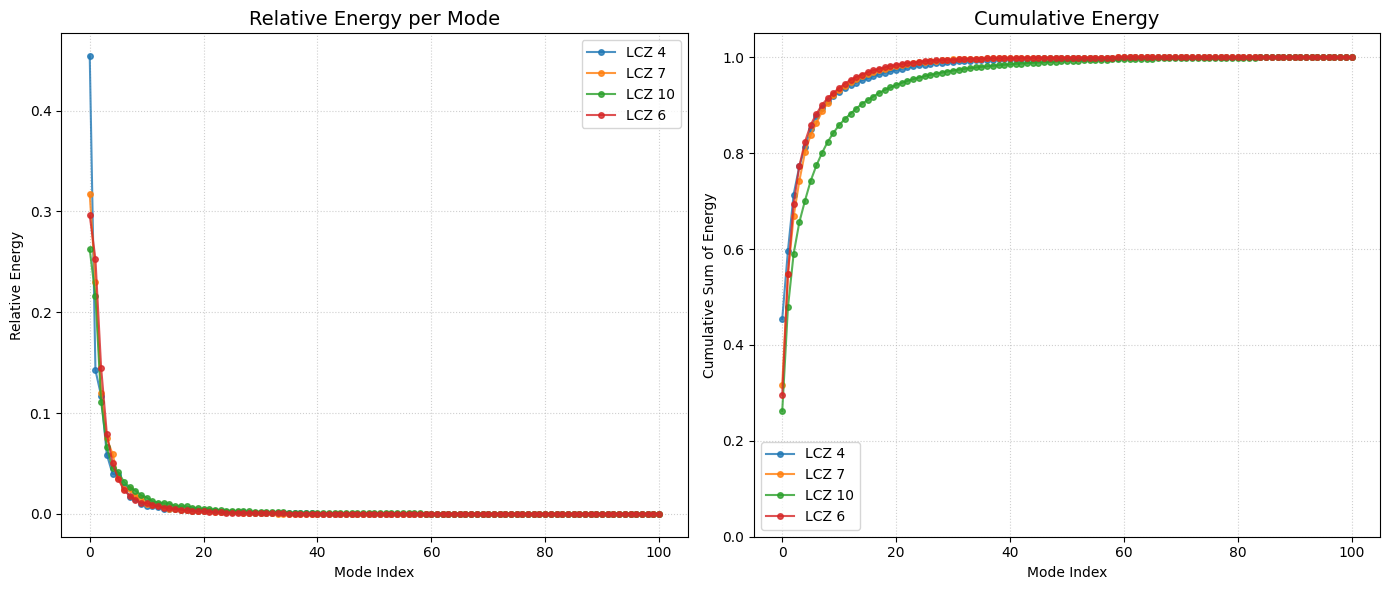

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# --- 1. 配置映射关系 ---
label_map = {
    'Run2': 'LCZ 6',
    'Run10': 'LCZ 4',
    'Run11': 'LCZ 7',
    'Run12': 'LCZ 10'
}

# 筛选出所有能量谱文件
energy_files = glob.glob('../../dataset/POD/Run*/pod_energy_spectrum.csv')
energy_files.sort()

# --- 2. 初始化画布 (1行2列) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- 3. 循环读取并绘制 ---
for file_path in energy_files:
    # 提取 Run 编号
    run_id = file_path.split(os.sep)[-2]
    if run_id not in label_map:
        continue
    
    label_name = label_map[run_id]
    
    # 读取数据
    # 假设 csv 第一列是索引/模态阶数，第二列是相对能量值
    df = pd.read_csv(file_path)
    modes = df.iloc[:, 0]
    energy_values = df.iloc[:, 1]
    cumulative_energy = df.iloc[:, 2]

    # 计算累积能量
    
    # 绘制左图：Relative Energy (使用线图+散点以便对比多个 Run)
    ax1.plot(modes, energy_values, label=label_name, marker='o', markersize=4, alpha=0.8)
    
    # 绘制右图：Cumulative Energy
    ax2.plot(modes, cumulative_energy, label=label_name, marker='o', markersize=4, alpha=0.8)

# --- 4. 美化图表 ---
# 左图设置
ax1.set_title('Relative Energy per Mode', fontsize=14)
ax1.set_xlabel('Mode Index')
ax1.set_ylabel('Relative Energy')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# 右图设置
ax2.set_title('Cumulative Energy', fontsize=14)
ax2.set_xlabel('Mode Index')
ax2.set_ylabel('Cumulative Sum of Energy')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.set_ylim(0, 1.05) # 能量累积最高为1

plt.tight_layout()
plt.show()

C:\Users\SCUT-WYX\AppData\Local\Temp\ipykernel_13888\4043664190.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


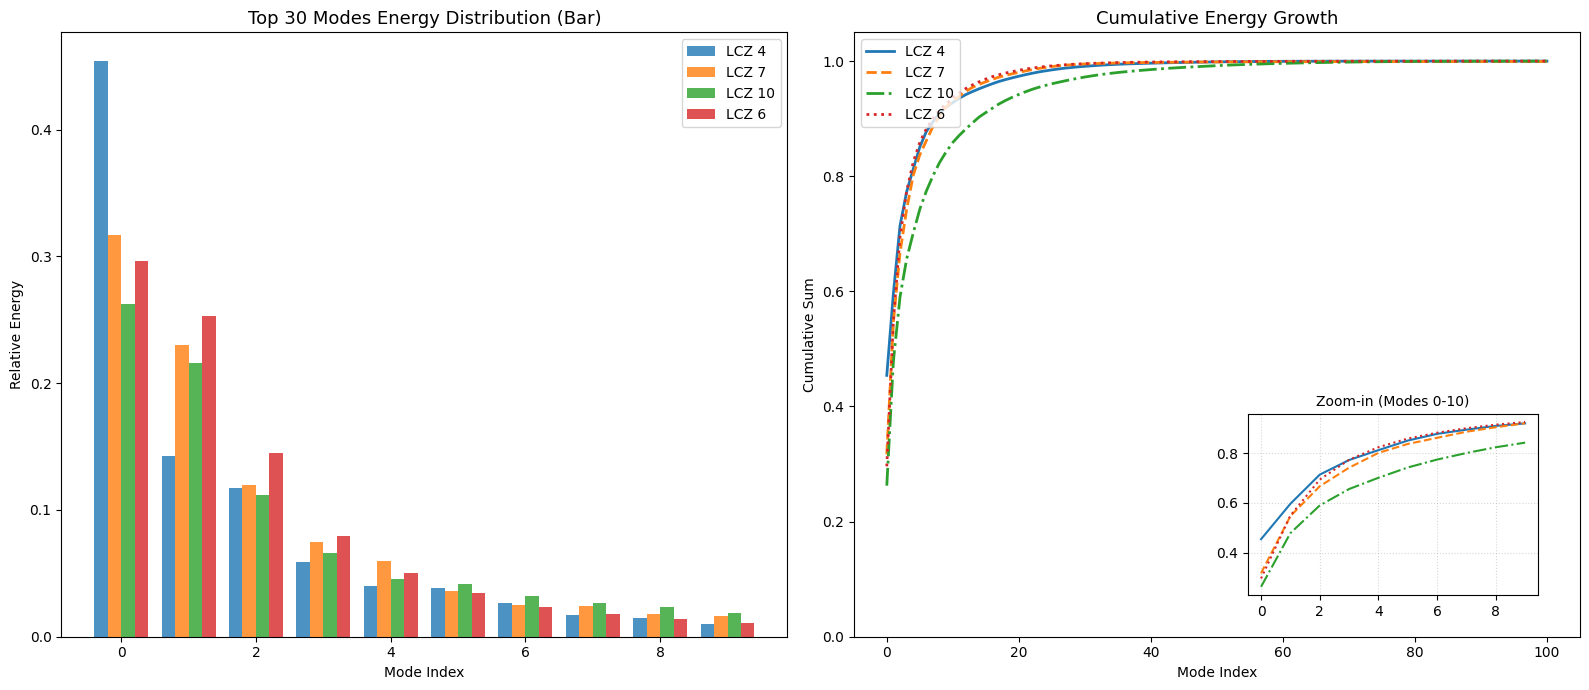

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes # 用于创建局部放大图

# --- 1. 配置映射与数据获取 ---
label_map = {'Run2': 'LCZ 6', 'Run10': 'LCZ 4', 'Run11': 'LCZ 7', 'Run12': 'LCZ 10'}
energy_files = glob.glob('../../dataset/POD/Run*/pod_energy_spectrum.csv')
energy_files.sort()

# --- 2. 初始化画布 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
linestyles = ['-', '--', '-.', ':']

# 创建右图的局部放大坐标系 (在 ax2 中间偏下的位置)
axins = inset_axes(ax2, width="40%", height="30%", loc='lower right', borderpad=3)

# --- 3. 循环绘图 ---
for i, file_path in enumerate(energy_files):
    run_id = file_path.split(os.sep)[-2]
    if run_id not in label_map: continue
    
    label_name = label_map[run_id]
    df = pd.read_csv(file_path)
    modes = df.iloc[:, 0]
    energy_values = df.iloc[:, 1]
    cum_energy = np.cumsum(energy_values)
    
    # --- 左图：柱状图 (采用较细的柱子并列或重叠) ---
    # 为了避免拥挤，只画前 30 个模态，使用 width 偏移实现并列
    width = 0.2
    ax1.bar(modes[:10] + (i-1.5)*width, energy_values[:10], width=width, 
            label=label_name, color=colors[i], alpha=0.8)
    
    # --- 右图：累积能量 (增加线型区分) ---
    ax2.plot(modes, cum_energy, label=label_name, color=colors[i], 
             linestyle=linestyles[i], linewidth=2)
    
    # --- 局部放大图：只画前 10 阶 ---
    axins.plot(modes[:10], cum_energy[:10], color=colors[i], 
               linestyle=linestyles[i], linewidth=1.5)

# --- 4. 细节美化 ---
# 左图美化
ax1.set_title('Top 30 Modes Energy Distribution (Bar)', fontsize=13)
ax1.set_xlabel('Mode Index')
ax1.set_ylabel('Relative Energy')
ax1.legend()

# 右图美化
ax2.set_title('Cumulative Energy Growth', fontsize=13)
ax2.set_xlabel('Mode Index')
ax2.set_ylabel('Cumulative Sum')
ax2.set_ylim(0, 1.05)
ax2.legend(loc='upper left')

# 放大图美化
axins.set_title('Zoom-in (Modes 0-10)', fontsize=10)
axins.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\SCUT-WYX\AppData\Local\Temp\ipykernel_22796\3546911497.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()


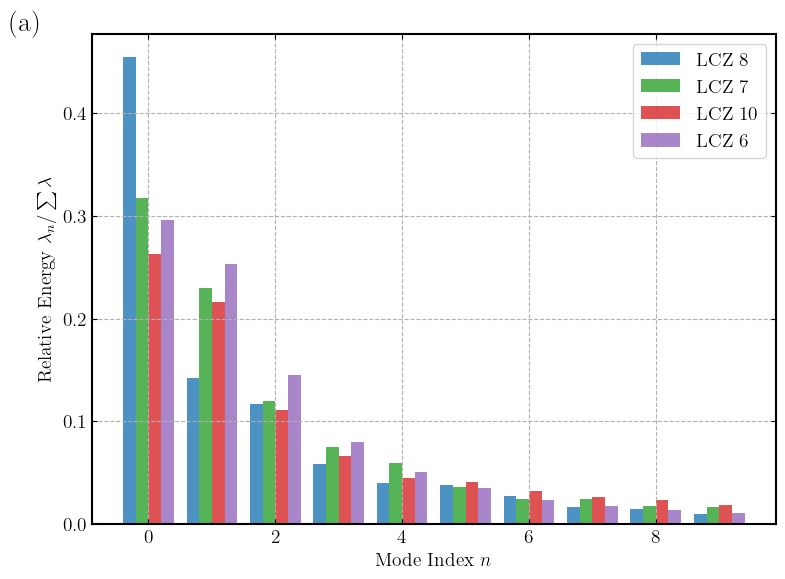

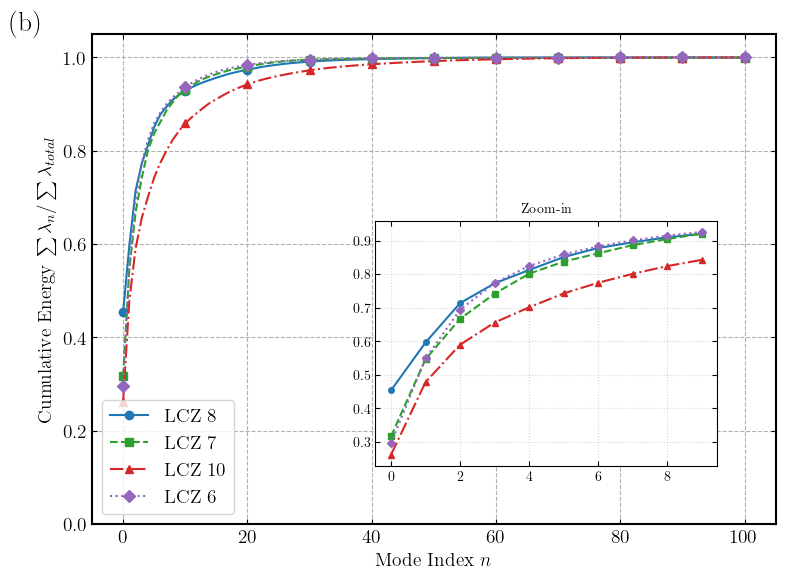

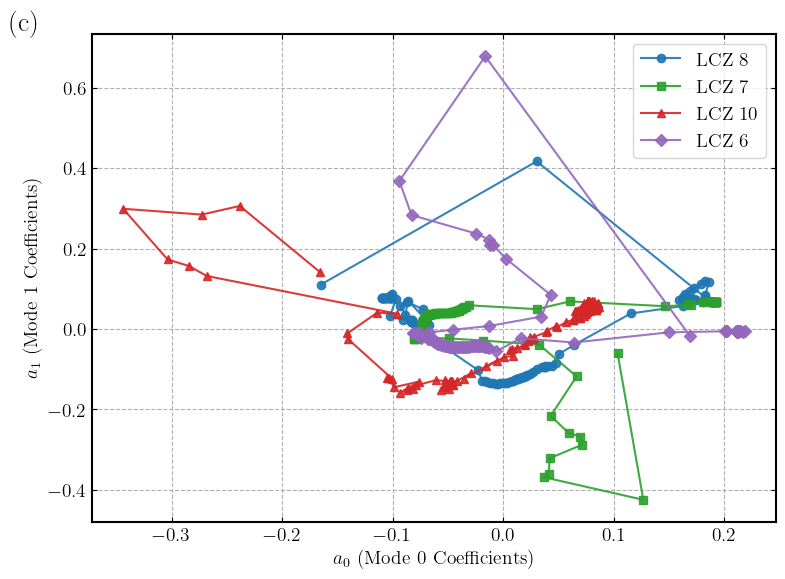

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes 

# --- 1. 基础配置 ---
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'text.usetex': True, 
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.unicode_minus': False 
})

label_map = {'Run2': 'LCZ 6', 'Run11': 'LCZ 7', 'Run10': 'LCZ 8', 'Run12': 'LCZ 10'}
run_folders = glob.glob('../../dataset/POD/Run*')
run_folders.sort()

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'D']

# 公共标签放置函数
def add_label(ax, label):
    # x=0.02, y=0.95 对应左上角
    ax.text(-0.12, 1.05, label, transform=ax.transAxes, 
            fontsize=20, fontweight='bold', va='top', ha='left')
    
# ---------------------------------------------------------
# 图 (a): Relative Energy Distribution (Bar)
# ---------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8, 6))
plot_idx = 0
for folder in run_folders:
    run_id = os.path.basename(folder)
    if run_id not in label_map: continue
    
    path = os.path.join(folder, 'pod_energy_spectrum.csv')
    if os.path.exists(path):
        df = pd.read_csv(path)
        width = 0.2
        ax1.bar(df.iloc[:10, 0] + (plot_idx-1.5)*width, df.iloc[:10, 1], 
                width=width, label=label_map[run_id], color=colors[plot_idx], alpha=0.8)
    plot_idx += 1

ax1.set_xlabel(r'Mode Index $n$')
ax1.set_ylabel(r'Relative Energy $\lambda_n / \sum \lambda$')
ax1.legend(frameon=True)
ax1.grid(True, linestyle='--')
for spine in ax1.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')
add_label(ax1, '(a)')
fig1.tight_layout()

plt.savefig('Fig9(a).png', dpi=600, bbox_inches='tight')

# ---------------------------------------------------------
# 图 (b): Cumulative Energy Growth (带局部放大)
# ---------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 6))

# 创建局部放大图：放置在右下角 (lower right)
axins = inset_axes(ax2, width="50%", height="50%", loc='lower right', borderpad=3)

plot_idx = 0
for folder in run_folders:
    run_id = os.path.basename(folder)
    if run_id not in label_map: continue
    
    path = os.path.join(folder, 'pod_energy_spectrum.csv')
    if os.path.exists(path):
        df = pd.read_csv(path)
        modes = df.iloc[:, 0]
        cum_energy = np.cumsum(df.iloc[:, 1])
        
        # 主图绘制
        ax2.plot(modes, cum_energy, label=label_map[run_id], 
                 color=colors[plot_idx], linestyle=linestyles[plot_idx], 
                 marker=markers[plot_idx], markevery=10, markersize=6)
        
        # 放大图绘制 (仅绘制前 10 阶)
        axins.plot(modes[:10], cum_energy[:10], color=colors[plot_idx], 
                   linestyle=linestyles[plot_idx], marker=markers[plot_idx], markersize=4)
    plot_idx += 1

ax2.set_xlabel(r'Mode Index $n$')
ax2.set_ylabel(r'Cumulative Energy $\sum \lambda_n / \sum \lambda_{total}$')
ax2.set_ylim(0, 1.05)
ax2.legend(loc='lower left', frameon=True) # 调整图例位置避免挡住标签
ax2.grid(True, linestyle='--')
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')
add_label(ax2, '(b)')

# 美化放大子图
axins.set_title(r'Zoom-in', fontsize=10)
axins.tick_params(labelsize=10) # 减小子图刻度字体
axins.grid(True, linestyle=':', alpha=0.5)

fig2.tight_layout()

plt.savefig('Fig9(b).png', dpi=600, bbox_inches='tight')

# ---------------------------------------------------------
# 图 (c): Phase Plot (Mode 0 vs Mode 1)
# ---------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(8, 6))
plot_idx = 0
for folder in run_folders:
    run_id = os.path.basename(folder)
    if run_id not in label_map: continue
    
    path = os.path.join(folder, 'pod_phase_mode0_mode1.csv')
    if os.path.exists(path):
        df = pd.read_csv(path)
        ax3.plot(df.iloc[:, 0], df.iloc[:, 1], label=label_map[run_id], 
                 marker=markers[plot_idx], markersize=6,
                 color=colors[plot_idx], alpha=0.9)
    plot_idx += 1

for spine in ax3.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

ax3.set_xlabel(r'$a_0$ (Mode 0 Coefficients)')
ax3.set_ylabel(r'$a_1$ (Mode 1 Coefficients)')
#ax3.axis('equal')
ax3.legend(frameon=True)
ax3.grid(True, linestyle='--')
add_label(ax3, '(c)')

fig3.tight_layout()

plt.savefig('Fig9(c).png', dpi=600, bbox_inches='tight')

plt.show()

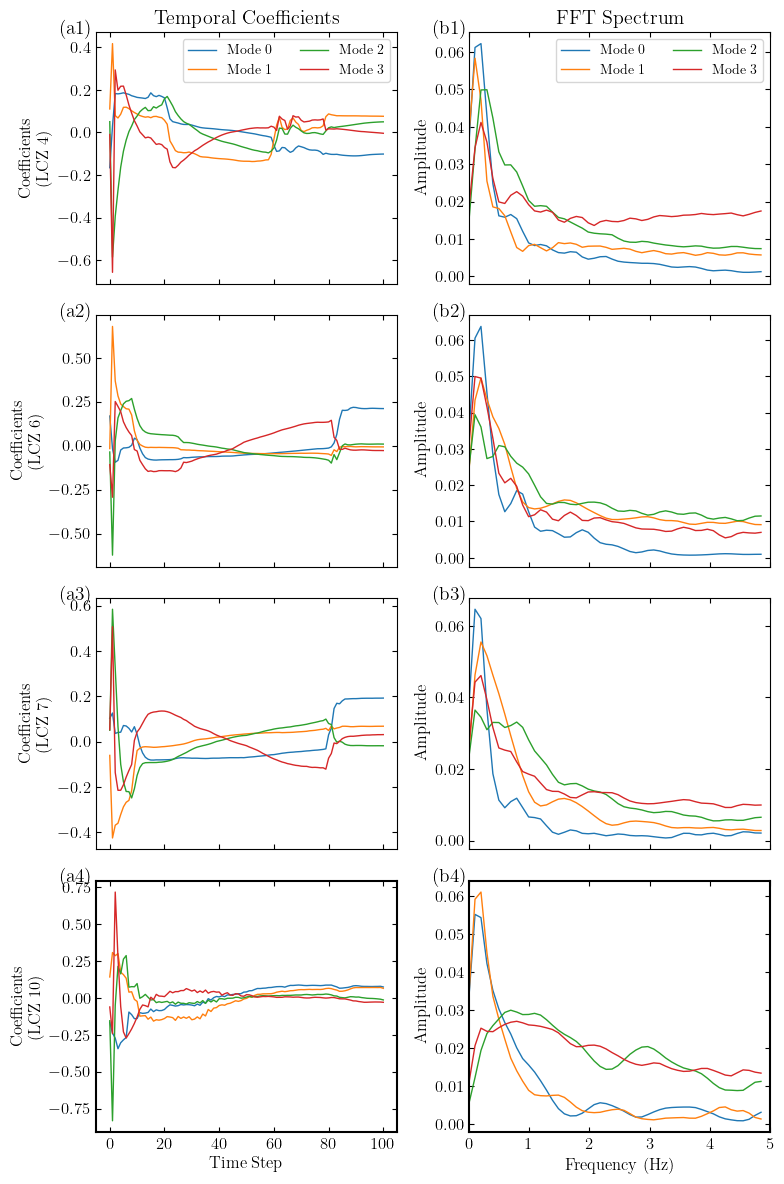

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.ndimage import gaussian_filter1d

# --- 1. 基础配置 ---
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'text.usetex': True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.unicode_minus': False
})

label_map = {'Run10': 'LCZ 4', 'Run2': 'LCZ 6', 'Run11': 'LCZ 7', 'Run12': 'LCZ 10'}
target_runs = ['Run10', 'Run2', 'Run11', 'Run12'] 
# 定义 4 个模态的颜色
mode_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

# --- 2. 创建画布 (4行2列) ---
fig, axes = plt.subplots(4, 2, figsize=(8, 12), sharex='col')

for i, run_id in enumerate(target_runs):
    folder = f'../../dataset/POD/{run_id}'
    label_name = label_map[run_id]
    
    # --- A. 绘制时间系数 (左列 - 包含 Mode 0-3) ---
    temp_path = os.path.join(folder, 'pod_temporal_coefficients.csv')
    if os.path.exists(temp_path):
        df_temp = pd.read_csv(temp_path)
        # 假设：第0列是时间，第1-4列分别是 Mode 0, 1, 2, 3
        time_data = df_temp.iloc[:1000, 0]
        
        for m in range(4):
            coeff_data = df_temp.iloc[:1000, m+1]
            axes[i, 0].plot(time_data, coeff_data, color=mode_colors[m], 
                           linewidth=1, label=f'Mode {m}')
        
        axes[i, 0].set_ylabel(f'Coefficients\n({label_name})')
        if i == 0: 
            axes[i, 0].set_title('Temporal Coefficients')
            axes[i, 0].legend(loc='upper right', frameon=True, fontsize=10, ncol=2)
        
    # --- B. 绘制 FFT 频谱 (右列 - 包含 Mode 0-3) ---
    fft_path = os.path.join(folder, 'pod_fft_spectrum.csv')
    if os.path.exists(fft_path):
        df_fft = pd.read_csv(fft_path)
        freq = df_fft.iloc[:, 0]
        
        for m in range(4):
            # 假设 FFT 文件中，每一列对应一个模态的幅值
            amplitude = df_fft.iloc[:, m+1]
            amplitude_smooth = gaussian_filter1d(amplitude, sigma=1) # 略微平滑
            axes[i, 1].plot(freq, amplitude_smooth, color=mode_colors[m], 
                           linewidth=1, label=f'Mode {m}')
        
        # 参照你的示例图，限制一下频谱显示范围提高对比度
        axes[i, 1].set_xlim(0, 5) 
        axes[i, 1].set_ylabel('Amplitude')
        if i == 0: 
            axes[i, 1].set_title('FFT Spectrum')
            axes[i, 1].legend(loc='upper right', frameon=True, fontsize=10, ncol=2)

    # --- C. 添加普通字体角标 (左上角) ---
    axes[i, 0].text(-0.12, 1.05, f'(a{i+1})', transform=axes[i, 0].transAxes, fontsize=14, va='top')
    axes[i, 1].text(-0.12, 1.05, f'(b{i+1})', transform=axes[i, 1].transAxes, fontsize=14, va='top')

# 设置最底部的 X 轴标签
axes[3, 0].set_xlabel('Time Step')
axes[3, 1].set_xlabel('Frequency (Hz)')

# 加粗边框 

for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')



plt.tight_layout()
plt.show()

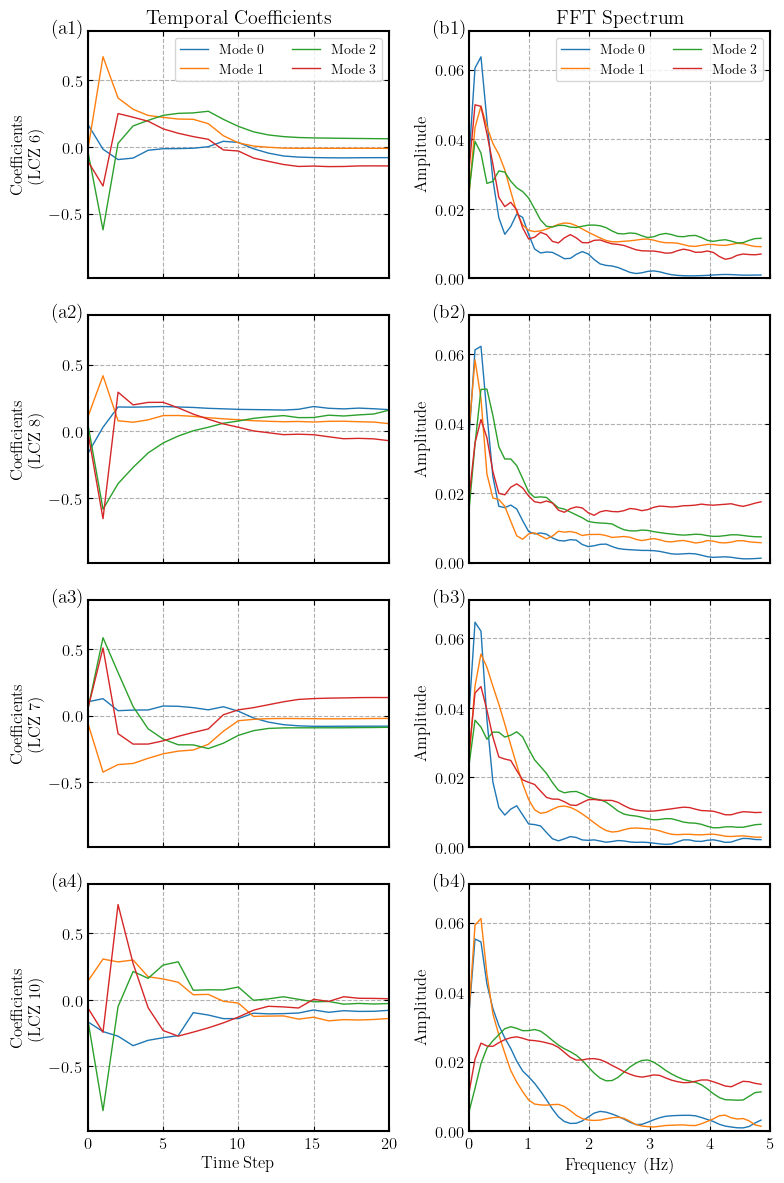

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.ndimage import gaussian_filter1d

# --- 1. 基础配置 ---
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'text.usetex': True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.unicode_minus': False
})

label_map = {'Run10': 'LCZ 8', 'Run2': 'LCZ 6', 'Run11': 'LCZ 7', 'Run12': 'LCZ 10'}
target_runs = ['Run2','Run10','Run11', 'Run12'] 
mode_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

# --- 2. 创建画布 ---
fig, axes = plt.subplots(4, 2, figsize=(8, 12), sharex='col')

# 用于存储纵坐标极值的变量
y_coeff_min, y_coeff_max = 0, 0
y_fft_max = 0

# --- 3. 第一次遍历：绘图并计算极值 ---
for i, run_id in enumerate(target_runs):
    folder = f'../../dataset/POD/{run_id}'
    label_name = label_map[run_id]
    
    # --- A. 时间系数 ---
    temp_path = os.path.join(folder, 'pod_temporal_coefficients.csv')
    if os.path.exists(temp_path):
        df_temp = pd.read_csv(temp_path)
        time_data = df_temp.iloc[:1000, 0]
        for m in range(4):
            coeff_data = df_temp.iloc[:1000, m+1]
            axes[i, 0].plot(time_data, coeff_data, color=mode_colors[m], linewidth=1, label=f'Mode {m}')
            # 更新极值
            y_coeff_min = min(y_coeff_min, coeff_data.min())
            y_coeff_max = max(y_coeff_max, coeff_data.max())
        axes[i, 0].set_xlim(0, 20)
        axes[i, 0].set_ylabel(f'Coefficients\n({label_name})')
        axes[i, 0].grid(True, linestyle='--')
        if i == 0: 
            axes[i, 0].set_title('Temporal Coefficients')
            axes[i, 0].legend(loc='upper right', frameon=True, fontsize=10, ncol=2)
        
    # --- B. FFT 频谱 ---
    fft_path = os.path.join(folder, 'pod_fft_spectrum.csv')
    if os.path.exists(fft_path):
        df_fft = pd.read_csv(fft_path)
        freq = df_fft.iloc[:, 0]
        for m in range(4):
            amplitude = df_fft.iloc[:, m+1]
            amplitude_smooth = gaussian_filter1d(amplitude, sigma=1)
            axes[i, 1].plot(freq, amplitude_smooth, color=mode_colors[m], linewidth=1, label=f'Mode {m}')
            
            # 更新频谱最大值（频谱通常从0开始，只需关注最大值）
            # 仅在显示的频率范围内计算最大值 (0-5 Hz)
            mask = (freq >= 0) & (freq <= 5)
            y_fft_max = max(y_fft_max, amplitude_smooth[mask].max())
        
        axes[i, 1].set_xlim(0, 5) 
        axes[i, 1].set_ylabel('Amplitude')
        # 加上grid
        axes[i, 1].grid(True, linestyle='--')
        if i == 0: 
            axes[i, 1].set_title('FFT Spectrum')
            axes[i, 1].legend(loc='upper right', frameon=True, fontsize=10, ncol=2)

    # --- C. 角标 ---
    axes[i, 0].text(-0.12, 1.05, f'(a{i+1})', transform=axes[i, 0].transAxes, fontsize=14, va='top')
    axes[i, 1].text(-0.12, 1.05, f'(b{i+1})', transform=axes[i, 1].transAxes, fontsize=14, va='top')

# --- 4. 第二次遍历：统一纵坐标轴范围 ---
# 适当留白 (padding) 以防曲线贴边
coeff_buffer = (y_coeff_max - y_coeff_min) * 0.1
fft_buffer = y_fft_max * 0.1

for i in range(4):
    axes[i, 0].set_ylim(y_coeff_min - coeff_buffer, y_coeff_max + coeff_buffer)
    axes[i, 1].set_ylim(0, y_fft_max + fft_buffer)

# 设置最底部的 X 轴标签
axes[3, 0].set_xlabel('Time Step')
axes[3, 1].set_xlabel('Frequency (Hz)')

# 加粗边框 
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

plt.tight_layout()
plt.savefig('Fig10.jpg', dpi=600, bbox_inches='tight')
plt.show()

In [5]:
from PIL import Image

def merge_images_horizontal(image_paths, output_path):
    # 1. 打开所有图片
    images = [Image.open(x) for x in image_paths]
    
    # 2. 计算总宽度和最大高度
    total_width = max(img.width for img in images)
    max_height = sum(img.height for img in images)
    
    # 3. 创建空白画布 (RGB 模式)
    new_img = Image.new('RGB', (total_width, max_height), (255, 255, 255))
    
    # 4. 依次粘贴
    current_height = 0
    for img in images:
        new_img.paste(img, (0, current_height))
        current_height += img.height

    # 5. 保存
    new_img.save(output_path)
    print(f"拼接完成！已保存至: {output_path}")

# 使用示例
merge_images_horizontal(['Fig9(a).png', 'Fig9(b).png', 'Fig9(c).png'], 'Fig9.jpg')

拼接完成！已保存至: Fig9.jpg


In [6]:
from PIL import Image

def merge_2_top_1_center(image_paths, output_path):
    if len(image_paths) != 3:
        print("错误：请提供恰好3张图片路径")
        return

    # 1. 打开图片
    imgs = [Image.open(p) for p in image_paths]
    w, h = imgs[0].size  # 假设图片一样大
    
    # 2. 创建画布 (2w * 2h)
    # 背景设为白色 (255, 255, 255)
    canvas = Image.new('RGB', (w * 2, h * 2), (255, 255, 255))
    
    # 3. 粘贴第一行（左上，右上）
    canvas.paste(imgs[0], (0, 0))
    canvas.paste(imgs[1], (w, 0))
    
    # 4. 粘贴第二行（居中）
    # 居中坐标计算：(总宽 - 图片宽) // 2 -> (2w - w) // 2 = w // 2
    center_x = w // 2
    canvas.paste(imgs[2], (center_x, h))
    
    # 5. 保存
    canvas.save(output_path, quality=95)
    print(f"拼接完成！布局为上二下一（居中），保存至: {output_path}")

# 调用示例
merge_2_top_1_center(['Fig9(a).png', 'Fig9(b).png', 'Fig9(c).png'], 'pyramid_result.jpg')

拼接完成！布局为上二下一（居中），保存至: pyramid_result.jpg
